In [1]:
import jax
import jax.numpy as jnp
import optax
import matplotlib.pyplot as plt
import functions
import pybamm
import numpy as np
from tqdm import trange
import optuna
import os
from jaxlib.xla_extension import XlaRuntimeError
import gc

In [2]:
from FNO import *

In [3]:
def preprocess_data(train_I, train_c0, train_cn, train_Ds, t, t_max, padding_r, padding_t, num_samples_c0, num_samples_I):
    """
    Pre-process the dataset into channels and padded shapes suitable for the FNO.
    
    Parameters
    ----------
    train_I : np.ndarray
        Current samples of shape (num_samples, 75).
    train_c0 : np.ndarray
        Initial concentration samples of shape (num_samples, 20).
    train_cn : np.ndarray
        Target concentrations of shape (num_samples, 20, 75).

    Returns
    -------
    X : jnp.ndarray
        Preprocessed inputs of shape (num_samples, 24, 85, 4).
    Y : jnp.ndarray
        Preprocessed targets of shape (num_samples, 24, 85, 1).
    """

    num_samples = train_I.shape[0]
    t_lin = t/t_max
    R_orig, T_orig = np.meshgrid(r, t_lin, indexing='ij')  # (20,75) each

    R =np.pad(R_orig, ((padding_r, padding_r),(padding_t, padding_t)))
    T = np.pad(T_orig, ((padding_r, padding_r),(padding_t, padding_t)))
    # R, T now have shape (24,85)

    # Original resolutions without padding
    H_orig = num_samples_c0
    W_orig = num_samples_I

    H = H_orig + 2 * padding_r  # 20 + 2*2 = 24
    W = W_orig + 2 * padding_t  # 75 + 2*5 = 85


    # Prepare arrays for output
    X = np.zeros((num_samples, H, W, 4))
    Y = np.zeros((num_samples, H, W, 1))

    # Pad function
    def pad_along_time(arr, padding):
        # arr shape is (..., 75)
        return np.pad(arr, ((0,0), (padding, padding)))

    def pad_along_r(arr, padding):
        # arr shape is (..., 20)
        return np.pad(arr, ((0,0), (padding, padding)))

    # Pad I and c0 along appropriate axes
    # For each sample:
    # train_I[n]: shape (75,) -> pad to (85,)
    # train_c0[n]: shape (20,) -> pad to (24,)



    I_padded = pad_along_time(train_I, padding_t)    # (num_samples, 85)
    c0_padded = pad_along_r(train_c0, padding_r)      # (num_samples, 24)

    # Broadcast to (24,85) for each sample
    # I_padded: (num_samples, 85) -> (num_samples,24,85)
    # replicate along r-dim
    I_2D = np.tile(I_padded[:, None, :], (1, H, 1))

    # c0_padded: (num_samples,24) -> (num_samples,24,85)
    # replicate along t-dim
    c0_2D = np.tile(c0_padded[:, :, None], (1, 1, W))

    Ds_initial = np.repeat(train_Ds[:, None], H_orig, axis=1)  # (num_samples, 20)
    # Step 2: Pad the vector along the r-axis to get length 24
    Ds_padded = np.pad(Ds_initial, ((0, 0), (padding_r, padding_r)))  # (num_samples, 24)
    # Step 3: Replicate along t-axis to form a 2D field of shape (num_samples, 24, 85)
    Ds_2D = np.tile(Ds_padded[:, :, None], (1, 1, W))

    # R,T are the same for all samples, just expand
    R_3D = np.tile(R[None, ...], (num_samples, 1, 1)) # (num_samples,24,85)
    T_3D = np.tile(T[None, ...], (num_samples, 1, 1)) # (num_samples,24,85)

    # Stack channels: (num_samples,24,85,4)
    X = np.stack([I_2D, c0_2D, Ds_2D, R_3D, T_3D], axis=-1)

    # Process targets (train_cn): (num_samples,20,75)
    # pad targets along r and t to (24,85)
    # Along r: pad (20,) to (24,)
    # Along t: pad (75,) to (85,)

    # Pad cn along both dimensions:
    # We'll do this per-sample:
    cn_padded = np.pad(train_cn, ((0,0),(padding_r,padding_r),(padding_t,padding_t))) # (num_samples,24,85)

    # Add channel dimension for targets: (num_samples,24,85,1)
    Y = cn_padded[..., None]

    return X,Y#jax.device_put(X, cpu), jax.device_put(Y, cpu)

In [4]:
def data_loader(X: np.ndarray, Y: np.ndarray, batch_size: int, shuffle: bool = True):
    """
    A simple data loader that yields batches of preprocessed FNO data.
    
    Parameters
    ----------
    X : jnp.ndarray
        Preprocessed input data of shape (num_samples, 24,85,4).
    Y : jnp.ndarray
        Preprocessed target data of shape (num_samples, 24,85,1).
    batch_size : int
        Number of samples per batch.
    shuffle : bool
        Whether to shuffle the dataset before yielding batches.

    Yields
    ------
    (X_batch, Y_batch) : tuple of jnp.ndarray
        X_batch : (batch_size, 24,85,4)
        Y_batch : (batch_size, 24,85,1)
    """
    num_samples = X.shape[0]
    indices = np.arange(num_samples)
    if shuffle:
        np.random.shuffle(indices)
    for start_idx in range(0, num_samples, batch_size):
        batch_indices = indices[start_idx:start_idx+batch_size]
        yield X[batch_indices], Y[batch_indices]

In [5]:
def relative_l2_loss(pred, target):
    # pred and target: (K,) arrays
    norm_target = jnp.linalg.norm(target, 2)
    norm_diff = jnp.linalg.norm(pred - target, 2)
    # Handle the case when target is all zeros
    norm_target = jnp.where(norm_target == 0, 1e-12, norm_target)
    return norm_diff / norm_target

In [6]:
def scale_the_D(D, lower=-15, upper=-12):
    return 2*(D-lower)/(upper-lower) - 1

In [7]:
# Set random keys
main_key = jax.random.PRNGKey(0)
key_train, key_test = jax.random.split(main_key)

params_bat = pybamm.ParameterValues("Chen2020")

# # Hyperparameters
# num_train = 2200
# num_test = 220

C = params_bat["Nominal cell capacity [A.h]"]
Ran = params_bat["Negative particle radius [m]"]
Rca = params_bat["Positive particle radius [m]"]
t_max = 3600

In [8]:
def init_FNO(k_modes, fno_depth, hidden_channels, output_channels, num_samples_I, num_samples_c0, padding_r, padding_t):
    
    key_main = jax.random.PRNGKey(0)
    dummy_I = jax.random.normal(key_main, (num_samples_I,))  # shape (75,)
    dummy_c0 = jax.random.normal(key_main, (num_samples_c0,)) # shape (20,)
    dummy_Ds = jax.random.normal(key_main, (num_samples_c0,))

    # Choose one sample for I and c0
    I_single = dummy_I[0]   # scalar
    c0_single = dummy_c0[0] # scalar
    Ds_single = dummy_Ds[0] 


    # Original resolutions without padding
    H_orig = num_samples_c0
    W_orig = num_samples_I

    H = H_orig + 2 * padding_r  # 20 + 2*2 = 24
    W = W_orig + 2 * padding_t  # 75 + 2*5 = 85

    # Pad I along t-axis (turning a scalar into a vector of length W)
    # Here I_single is a scalar, we need a (W_orig,) vector. Let's assume we want a constant I for all t.
    # For a single dummy run, let's just create a constant vector from I_single:
    I_vector = jnp.full((W_orig,), I_single)
    I_padded = jnp.pad(I_vector, (padding_t, padding_t))  # shape (85,)

    # Pad c0 along r-axis (similarly create a vector from c0_single)
    c0_vector = jnp.full((H_orig,), c0_single)
    c0_padded = jnp.pad(c0_vector, (padding_r, padding_r))  # shape (24,)

    Ds_vector = jnp.full((H_orig,), Ds_single)
    Ds_padded = jnp.pad(Ds_vector, (padding_r, padding_r))

    # Create coordinate grids
    r_lin = jnp.linspace(0, 1, H)  # shape (24,)
    t_lin = jnp.linspace(0, 1, W)  # shape (85,)
    R, T = jnp.meshgrid(r_lin, t_lin, indexing='ij')  # R,T both (24,85)

    # Broadcast I_padded (85,) to (24,85)
    I_2D = jnp.tile(I_padded[None, :], (H, 1))   # (24,85)
    # Broadcast c0_padded (24,) to (24,85)
    c0_2D = jnp.tile(c0_padded[:, None], (1, W)) # (24,85)
    # Broadcast Ds_padded (24,) to (24, 85)
    Ds_2D = jnp.tile(Ds_padded[:, None], (1, W))

    # Stack all channels: (B,H,W,C) with B=1
    input_tensor = jnp.stack([I_2D, c0_2D, Ds_2D, R, T], axis=-1)   # (24,85,4)
    input_tensor = input_tensor[None, ...]  # Add batch dimension: (1,24,85,4)

    # Instantiate model
    model = FNO(k_modes=k_modes, fno_depth=fno_depth, hidden_channels=hidden_channels, output_channels=output_channels)

    # Initialize parameters
    init_key = jax.random.PRNGKey(42)
    params = model.init(init_key, input_tensor)

    # Forward pass
    out = model.apply(params, input_tensor)
    print("Input shape:", input_tensor.shape)  # should be (1,24,85,5)
    print("Output shape:", out.shape)  # should be (1,24,85,1)

    return model, params


In [9]:
family = "GRF_"
id  = "8"
path = "data/spm/diff_D/"
train_data = np.load(path + "train/" + family + "281600" + ".npz")
test_data = np.load(path + "test/" + family + "28160" + ".npz")

train_I = np.array(train_data["current"])
test_I = np.array(test_data["current"])

train_cn = np.array(train_data["target_concentration_anode"])
test_cn = np.array(test_data["target_concentration_anode"])

train_c0 = np.array(train_data["initial_concentration_anode"])
test_c0 = np.array(test_data["initial_concentration_anode"])

train_D = np.array(train_data["diffusivity_anode"])
test_D = np.array(test_data["diffusivity_anode"])

cpu = jax.devices("cpu")[0]
gpu = jax.devices("gpu")[0]  # Should be the GPU

train_ratio = train_c0.shape[0] / train_D.shape[0]
test_ratio = test_c0.shape[0] / test_D.shape[0]
if not (train_ratio+test_ratio).is_integer():
    raise ValueError(f"Ratio must be integer but got {train_ratio} and {test_ratio}")


train_D = np.repeat(train_D, int(train_ratio), axis=0)
test_D = np.repeat(test_D, int(test_ratio), axis = 0)

train_D = scale_the_D(train_D)
test_D = scale_the_D(test_D)

# Padding amounts
padding_t = 5  # along t-axis
padding_r = 2  # along r-axis

# Original sample counts
num_samples_I = 75
num_samples_c0 = 20

t = np.linspace(0, t_max, num_samples_I)
r = np.linspace(0, 1, num_samples_c0)


X_train, Y_train = preprocess_data(train_I, train_c0, train_cn, train_D, t, t_max, padding_r, padding_t, num_samples_c0, num_samples_I)
X_test, Y_test = preprocess_data(test_I, test_c0, test_cn, test_D, t, t_max, padding_r, padding_t, num_samples_c0, num_samples_I)

print("X_train shape:", X_train.shape, "dtype:", X_train.dtype)
print("Y_train shape:", Y_train.shape, "dtype:", Y_train.dtype)

X_train shape: (281600, 24, 85, 5) dtype: float64
Y_train shape: (281600, 24, 85, 1) dtype: float64


In [10]:
# def loss_fn(params, X_batch, Y_batch):
#     preds = model.apply(params, X_batch)  # (batch_size, H, W, 1)
#     # Compute mean squared error over all spatial points and batch
#     return relative_l2_loss(preds.flatten(), Y_batch.flatten())


# @jax.jit
# def train_step(params, opt_state, X_batch, Y_batch):
#     # Compute loss and grads
#     loss_value, grads = jax.value_and_grad(loss_fn)(model, params, X_batch, Y_batch)
    
#     # Update parameters
#     updates, opt_state = optimizer.update(grads, opt_state)
#     params = optax.apply_updates(params, updates)
    
#     return params, opt_state, loss_value

In [11]:
# def model_train(model, params_init, opt_state, num_epochs):

#     pbar = trange(num_epochs, desc="Training")

#     params = params_init

#     batch_size = 24

#     train_losses = []
#     test_losses = []

#     for epoch in pbar:

#         total_train_loss = 0.0
#         count = 0

#         for X_batch, Y_batch in data_loader(X_train, Y_train, batch_size):
#             params, opt_state, loss_value = train_step(params, opt_state, jnp.array(X_batch), jnp.array(Y_batch))
#             total_train_loss += loss_value
#             count += 1
        

#         total_test_loss = 0.0
#         count2 = 0

#         for X_batch, Y_batch in data_loader(X_test, Y_test, 200):
#             # test_pred = model.apply(params, jnp.array(X_batch))
#             loss_value = loss_fn(model, params, jnp.array(X_batch), jnp.array(Y_batch))
#             total_test_loss += loss_value
#             count2 += 1


#         # train_losses.append(total_train_loss)
#         # test_losses.append(total_test_loss)

#         avg_train_loss = total_train_loss / count
#         avg_test_loss = total_test_loss / count2

#         train_losses.append(avg_train_loss)
#         test_losses.append(avg_test_loss)

#         desc_str = f"Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Test Loss: {avg_test_loss:.4f}"
#         pbar.set_description_str(desc_str)

#     return params, train_losses, test_losses

In [12]:
X_train = X_train[:2000]
Y_train = Y_train[:2000]

In [13]:
best_model_store = {}

def objective(trial):
    try:
        # Suggest values for hyperparameters
        k_modes = trial.suggest_int("k_modes", 8, 20)  # Example range
        fno_depth = trial.suggest_int("fno_depth", 8, 128)
        hidden_channels = trial.suggest_int("hidden_channels", 50, 200)
        learning_rate = trial.suggest_categorical("learning_rate", [1e-4, 1e-3, 1e-2])
        num_epochs = 1#trial.suggest_int("num_epochs", 20, 50, step = 5)
        output_channels = 1

        if fno_depth*hidden_channels*k_modes>=100e3:
            print(f"Pruning trial {trial.number}..., because network size is: {fno_depth*hidden_channels*k_modes}")
            raise optuna.exceptions.TrialPruned()

        model, params_init = init_FNO(
            k_modes, fno_depth, hidden_channels, output_channels, 
            num_samples_I, num_samples_c0, padding_r, padding_t)

        optimizer = optax.adam(learning_rate)
        opt_state = optimizer.init(params_init)


        # Print hyperparameters for this iteration
        print(f"Trial {trial.number}: k_modes={k_modes}, fno_depth={fno_depth}, "
            f"hidden_channels={hidden_channels}, learning_rate={learning_rate}, "
            f"num_epochs={num_epochs}")


        def loss_fn(params, X_batch, Y_batch):
            preds = model.apply(params, X_batch)  # (batch_size, H, W, 1)
            # Compute mean squared error over all spatial points and batch
            return relative_l2_loss(preds.flatten(), Y_batch.flatten())

        @jax.jit
        def train_step(params, opt_state, X_batch, Y_batch):
            # Compute loss and grads
            loss_value, grads = jax.value_and_grad(loss_fn)(params, X_batch, Y_batch)
            
            # Update parameters
            updates, opt_state = optimizer.update(grads, opt_state)
            params = optax.apply_updates(params, updates)
            
            return params, opt_state, loss_value
        
        pbar = trange(num_epochs, desc="Training")

        params = params_init

        batch_size = 24

        train_losses = []
        test_losses = []

        for epoch in pbar:

            total_train_loss = 0.0
            count = 0

            for X_batch, Y_batch in data_loader(X_train, Y_train, batch_size):
                params, opt_state, loss_value = train_step(params, opt_state, jnp.array(X_batch), jnp.array(Y_batch))
                total_train_loss += loss_value
                count += 1
            

            total_test_loss = 0.0
            count2 = 0

            for X_batch, Y_batch in data_loader(X_test, Y_test, 200):
                # test_pred = model.apply(params, jnp.array(X_batch))
                loss_value = loss_fn(params, jnp.array(X_batch), jnp.array(Y_batch))
                total_test_loss += loss_value
                count2 += 1


            # train_losses.append(total_train_loss)
            # test_losses.append(total_test_loss)

            avg_train_loss = total_train_loss / count
            avg_test_loss = total_test_loss / count2

            train_losses.append(avg_train_loss)
            test_losses.append(avg_test_loss)

            desc_str = f"Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Test Loss: {avg_test_loss:.4f}"
            pbar.set_description_str(desc_str)

        best_model_store[trial.number] = {
            "hyperparams": {
                "k_modes": k_modes,
                "fno_depth": fno_depth,
                "hidden_channels": hidden_channels,
                "learning_rate": learning_rate,
                "num_epochs": num_epochs
            },
            "model_def": model,          # The model "structure" (if needed)
            "trained_params": params,
            "test_losses": test_losses,
            "train_losses": train_losses
        }

        return test_losses[-1]  # Assuming lower loss is better

    except (XlaRuntimeError, ValueError, RuntimeError) as e:
        print(f"OOM encountered: {e}. Pruning trial {trial.number}...")
        raise optuna.exceptions.TrialPruned()
    
    finally:
        gc.collect()



In [14]:
# Run optimization
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=5)

[I 2025-03-20 13:45:46,810] A new study created in memory with name: no-name-691adba9-deb9-4903-ae1b-e4ccb72f6875


Input shape: (1, 24, 85, 5)
Output shape: (1, 24, 85, 1)
Trial 0: k_modes=10, fno_depth=36, hidden_channels=175, learning_rate=0.001, num_epochs=1


Training:   0%|          | 0/1 [02:37<?, ?it/s]
[W 2025-03-20 13:48:27,656] Trial 0 failed with parameters: {'k_modes': 10, 'fno_depth': 36, 'hidden_channels': 175, 'learning_rate': 0.001} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/home/dlu-apa/.pyenv/versions/3.11.5/lib/python3.11/site-packages/optuna/study/_optimize.py", line 197, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_36835/3403124414.py", line 72, in objective
    loss_value = loss_fn(params, jnp.array(X_batch), jnp.array(Y_batch))
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_36835/3403124414.py", line 32, in loss_fn
    preds = model.apply(params, X_batch)  # (batch_size, H, W, 1)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/dlu-apa/.pyenv/versions/3.11.5/lib/python3.11/site-packages/jax/_src/traceback_util.py", line 180, in reraise_with_filtered_traceb

KeyboardInterrupt: 

In [ ]:
# Retrieve the *trial number* of the best run
best_trial_number = study.best_trial.number
best_stored = best_model_store[best_trial_number]

In [ ]:
train_losses = best_stored["train_losses"]
test_losses = best_stored["test_losses"]
best_params = best_stored["trained_params"]

print("Best hyperparams:", best_stored["hyperparams"])
print("Test Loss:", test_losses[-1])

Best hyperparams: {'k_modes': 14, 'fno_depth': 59, 'hidden_channels': 52, 'learning_rate': 0.01, 'num_epochs': 1}
Test Loss: 0.96324575


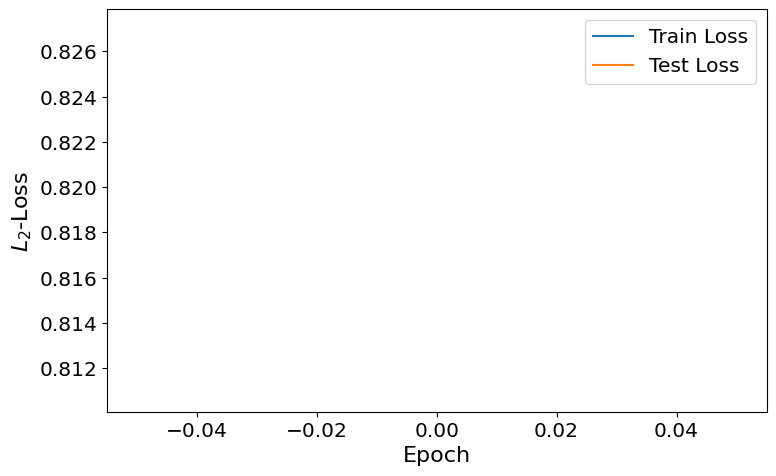

In [ ]:
# Set global font sizes
plt.rcParams.update({
    'font.size': 14.5,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14.5,
    'ytick.labelsize': 14.5,
    'legend.fontsize': 14.5,
    'figure.titlesize': 20
})

# After training, plot results
plt.figure(figsize=(8,5))
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('$L_2$-Loss')
#plt.title('Training vs Test Loss (Bias-Variance)')
plt.legend()
#plt.grid(True)
plt.tight_layout()
#plt.savefig("DON/Loss_DON" + ".svg", format='svg', transparent=True)
plt.show()

In [ ]:
filename = functions.save_model_params(best_params, directory = "./trained_models/diff_D", family = family)

Saved model parameters to ./trained_models/diff_D/anode_GRF__2025-03-20_13-24-32.msgpack
